In [487]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ---------------------------------------------------------
# 1. Dataset class: Session-isolated sliding windows
# ---------------------------------------------------------
class GaitSessionDataset(Dataset):
    def __init__(self, df, input_cols, target_cols, allowed_session_ids, window_size=128, stride=32, session_col='Session_ID'):
        """
        :param df: Full pandas DataFrame.
        :param allowed_session_ids: Session IDs assigned to this split.
        :param window_size: Window length.
        :param stride: Sliding-window stride inside each Session.
        :param session_col: Column that stores the Session ID.
        """
        self.input_names = input_cols
        self.target_names = target_cols
        self.session_ids = list(allowed_session_ids)
        self.window_size = window_size
        self.stride = stride
        self.X = []
        self.Y = []
        self.window_session_ids = []

        subset_df = df[df[session_col].isin(allowed_session_ids)].copy()
        grouped = subset_df.groupby(session_col, sort=False)

        processed_count = 0
        skipped_sessions = []

        for session_id, group in grouped:
            if len(group) < window_size:
                skipped_sessions.append(session_id)
                continue

            x_data = group[input_cols].values
            y_data = group[target_cols].values

            for i in range(0, len(group) - window_size + 1, stride):
                self.X.append(x_data[i : i + window_size])
                self.Y.append(y_data[i : i + window_size])
                self.window_session_ids.append(session_id)

            processed_count += 1

        if len(self.X) > 0:
            self.X = np.array(self.X, dtype=np.float32).transpose(0, 2, 1)
            self.Y = np.array(self.Y, dtype=np.float32).transpose(0, 2, 1)
        else:
            self.X = np.empty((0, len(input_cols), window_size), dtype=np.float32)
            self.Y = np.empty((0, len(target_cols), window_size), dtype=np.float32)

        print(f"Dataset built: {processed_count} Session(s), {len(self.X)} window sample(s).")
        if skipped_sessions:
            print(f"Skipped short Session(s) with fewer than {window_size} rows: {skipped_sessions}")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.from_numpy(self.Y[idx])


def list_available_sessions(csv_path, session_col='Session_ID'):
    """Show available sessions and row counts so train/test IDs can be chosen manually."""
    df = pd.read_csv(csv_path, usecols=[session_col])
    session_table = (
        df[session_col]
        .value_counts(sort=False)
        .rename_axis(session_col)
        .reset_index(name='rows')
    )
    print(f"Found {len(session_table)} Session(s) in {csv_path}.")
    try:
        display(session_table)
    except NameError:
        print(session_table.to_string(index=False))
    return session_table


def _display_session_ids(session_ids):
    """Return Session IDs as notebook-friendly Python scalars for printing."""
    return [sid.item() if hasattr(sid, 'item') else sid for sid in session_ids]


def _resolve_session_ids(session_ids, all_sessions, split_name):
    """Map user-entered Session IDs back to the dtype used in the CSV and validate them."""
    if session_ids is None:
        return None

    lookup = {str(s): s for s in all_sessions}
    resolved = []
    missing = []

    for sid in session_ids:
        key = str(sid)
        if key in lookup:
            resolved.append(lookup[key])
        else:
            missing.append(sid)

    if missing:
        raise ValueError(
            f"Unknown {split_name} Session ID(s): {missing}. "
            f"Available Session IDs are: {_display_session_ids(all_sessions)}"
        )

    duplicates = [sid for sid in resolved if resolved.count(sid) > 1]
    if duplicates:
        raise ValueError(f"Duplicate {split_name} Session ID(s): {sorted(set(duplicates), key=str)}")

    return np.array(resolved, dtype=object)


def choose_train_test_sessions(all_sessions, train_session_ids=None, test_session_ids=None,
                               num_train_sessions=None, num_test_sessions=None,
                               test_size=0.2, random_state=42):
    """
    Select train/test Session IDs.

    Preferred mode:
      TRAIN_SESSION_IDS = [0, 1, 2]
      TEST_SESSION_IDS = [3]

    Validation Session IDs are created automatically from TRAIN_SESSION_IDS later.
    If only one explicit list is provided, the other split uses the remaining sessions.
    If neither list is provided, this falls back to a random train/test split.
    """
    all_sessions = np.array(list(all_sessions), dtype=object)
    train_ids = _resolve_session_ids(train_session_ids, all_sessions, 'train')
    test_ids = _resolve_session_ids(test_session_ids, all_sessions, 'test')

    if train_ids is not None or test_ids is not None:
        if train_ids is None:
            train_ids = np.array([sid for sid in all_sessions if sid not in set(test_ids)], dtype=object)
        if test_ids is None:
            test_ids = np.array([sid for sid in all_sessions if sid not in set(train_ids)], dtype=object)
    elif num_train_sessions is not None or num_test_sessions is not None:
        if num_train_sessions is None or num_test_sessions is None:
            raise ValueError("Set both num_train_sessions and num_test_sessions, or use explicit session ID lists.")
        total_requested = num_train_sessions + num_test_sessions
        if total_requested > len(all_sessions):
            raise ValueError(
                f"Requested {total_requested} Session(s), but only {len(all_sessions)} are available."
            )
        rng = np.random.default_rng(random_state)
        shuffled_sessions = rng.permutation(all_sessions)
        train_ids = shuffled_sessions[:num_train_sessions]
        test_ids = shuffled_sessions[num_train_sessions : num_train_sessions + num_test_sessions]
    else:
        train_ids, test_ids = train_test_split(all_sessions, test_size=test_size, random_state=random_state)

    overlap = sorted(set(train_ids).intersection(set(test_ids)), key=str)
    if overlap:
        raise ValueError(f"Train/test Session IDs overlap: {overlap}")
    if len(train_ids) == 0 or len(test_ids) == 0:
        raise ValueError("Train and test splits must both contain at least one Session.")

    print(f"Train Session pool ({len(train_ids)}): {_display_session_ids(train_ids)}")
    print(f"Test Session IDs ({len(test_ids)}): {_display_session_ids(test_ids)}")
    return np.array(train_ids, dtype=object), np.array(test_ids, dtype=object)


def split_train_sessions_for_validation(train_session_ids, validation_size=0.2, random_state=42):
    """Reserve validation Session IDs from TRAIN_SESSION_IDS."""
    train_session_ids = np.array(list(train_session_ids), dtype=object)
    if len(train_session_ids) < 2:
        raise ValueError(
            "Need at least 2 TRAIN_SESSION_IDS to create an automatic validation split. "
            "Add more training sessions or provide a separate validation workflow."
        )

    actual_train_ids, val_ids = train_test_split(
        train_session_ids,
        test_size=validation_size,
        random_state=random_state,
    )

    if len(actual_train_ids) == 0 or len(val_ids) == 0:
        raise ValueError("Automatic train/validation split produced an empty split.")

    print(f"Final Train Session IDs ({len(actual_train_ids)}): {_display_session_ids(actual_train_ids)}")
    print(
        f"Validation Session IDs from TRAIN_SESSION_IDS "
        f"({len(val_ids)}, validation_size={validation_size}): {_display_session_ids(val_ids)}"
    )
    return np.array(actual_train_ids, dtype=object), np.array(val_ids, dtype=object)


# ---------------------------------------------------------
# 2. Data preparation: explicit train/test Session split + automatic validation split
# ---------------------------------------------------------
def prepare_session_split_data(csv_path, input_sensors, target_sensors, window_size=128, batch_size=32,
                               train_session_ids=None, test_session_ids=None,
                               num_train_sessions=None, num_test_sessions=None,
                               validation_size=0.2,
                               train_stride=32, val_stride=64, test_stride=64,
                               test_size=0.2, random_state=42,
                               session_col='Session_ID'):
    print(f"Reading data: {csv_path} ...")
    df = pd.read_csv(csv_path)

    if session_col not in df.columns:
        raise ValueError(f"Column '{session_col}' was not found in {csv_path}.")

    def find_cols(sensors, must_include=None):
        cols = []
        seen = set()
        for s in sensors:
            sensor_prefixes = (f"{s}_acc_", f"{s}_gyro_")
            candidates = [c for c in df.columns if c.startswith(sensor_prefixes)]
            if must_include:
                candidates = [c for c in candidates if must_include in c]
            for c in candidates:
                if c not in seen:
                    cols.append(c)
                    seen.add(c)
        return cols

    in_cols = find_cols(input_sensors, must_include='_filtered')
    tgt_cols = find_cols(target_sensors, must_include='_filtered')
    all_process_cols = in_cols + tgt_cols
    print(f"Input columns ({len(in_cols)}): {in_cols}")
    print(f"Target columns ({len(tgt_cols)}): {tgt_cols}")

    if not in_cols:
        raise ValueError(f"No input columns found for sensors: {input_sensors}")
    if not tgt_cols:
        raise ValueError(f"No target columns found for sensors: {target_sensors}")

    all_sessions = df[session_col].dropna().unique()
    print(f"Found {len(all_sessions)} independent Session(s).")
    train_pool_ids, test_ids = choose_train_test_sessions(
        all_sessions,
        train_session_ids=train_session_ids,
        test_session_ids=test_session_ids,
        num_train_sessions=num_train_sessions,
        num_test_sessions=num_test_sessions,
        test_size=test_size,
        random_state=random_state,
    )
    train_ids, val_ids = split_train_sessions_for_validation(
        train_pool_ids,
        validation_size=validation_size,
        random_state=random_state,
    )

    overlaps = {
        'train/validation': set(train_ids).intersection(set(val_ids)),
        'train/test': set(train_ids).intersection(set(test_ids)),
        'validation/test': set(val_ids).intersection(set(test_ids)),
    }
    overlap_text = {name: sorted(values, key=str) for name, values in overlaps.items() if values}
    if overlap_text:
        raise ValueError(f"Session splits overlap: {overlap_text}")

    scaler = StandardScaler()
    train_mask = df[session_col].isin(train_ids)
    val_mask = df[session_col].isin(val_ids)
    test_mask = df[session_col].isin(test_ids)

    scaler.fit(df.loc[train_mask, all_process_cols].values)
    df.loc[train_mask, all_process_cols] = scaler.transform(df.loc[train_mask, all_process_cols].values)
    df.loc[val_mask, all_process_cols] = scaler.transform(df.loc[val_mask, all_process_cols].values)
    df.loc[test_mask, all_process_cols] = scaler.transform(df.loc[test_mask, all_process_cols].values)

    train_dataset = GaitSessionDataset(
        df, in_cols, tgt_cols,
        allowed_session_ids=train_ids,
        window_size=window_size,
        stride=train_stride,
        session_col=session_col,
    )
    val_dataset = GaitSessionDataset(
        df, in_cols, tgt_cols,
        allowed_session_ids=val_ids,
        window_size=window_size,
        stride=val_stride,
        session_col=session_col,
    )
    test_dataset = GaitSessionDataset(
        df, in_cols, tgt_cols,
        allowed_session_ids=test_ids,
        window_size=window_size,
        stride=test_stride,
        session_col=session_col,
    )

    if len(train_dataset) == 0:
        raise ValueError("Training split generated 0 windows. Choose longer sessions, reduce WINDOW_SIZE, or reduce train_stride.")
    if len(val_dataset) == 0:
        raise ValueError("Validation split generated 0 windows. Choose longer sessions, reduce WINDOW_SIZE, or reduce val_stride.")
    if len(test_dataset) == 0:
        raise ValueError("Test split generated 0 windows. Choose longer sessions, reduce WINDOW_SIZE, or reduce test_stride.")

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader, len(in_cols), len(tgt_cols), scaler, all_process_cols


In [488]:
import torch
import torch.nn as nn
from torch.nn.utils import weight_norm

class Chomp1d(nn.Module):
    """
    裁剪模块：用于移除卷积后的右侧填充，确保因果性（不看未来的数据）。
    """
    def __init__(self, chomp_size):
        super(Chomp1d, self).__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size].contiguous()

class TemporalBlock(nn.Module):
    def __init__(self, n_inputs, n_outputs, kernel_size, stride, dilation, padding, dropout=0.2):
        super(TemporalBlock, self).__init__()
        
        # 第一个卷积层
        self.conv1 = weight_norm(nn.Conv1d(n_inputs, n_outputs, kernel_size,
                                   stride=stride, padding=padding, dilation=dilation))
        self.chomp1 = Chomp1d(padding) # 裁剪掉多余的 padding
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        # 第二个卷积层
        self.conv2 = weight_norm(nn.Conv1d(n_outputs, n_outputs, kernel_size,
                                           stride=stride, padding=padding, dilation=dilation))
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(self.conv1, self.chomp1, self.relu1, self.dropout1,
                                 self.conv2, self.chomp2, self.relu2, self.dropout2)
        
        # 残差连接：如果输入输出通道不一致，用 1x1 卷积调整
        self.downsample = nn.Conv1d(n_inputs, n_outputs, 1) if n_inputs != n_outputs else None
        self.relu = nn.ReLU()
        self.init_weights()

    def init_weights(self):
        self.conv1.weight.data.normal_(0, 0.01)
        self.conv2.weight.data.normal_(0, 0.01)
        if self.downsample is not None:
            self.downsample.weight.data.normal_(0, 0.01)

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

class GaitRNN(nn.Module):
    def __init__(self, num_inputs, num_outputs, hidden_size=128, num_layers=2, dropout=0.2):
        super(GaitRNN, self).__init__()
        

        self.num_outputs = num_outputs
        
        # LSTM 层
        # batch_first=True 表示输入格式为 (Batch, Length, Features)
        self.lstm = nn.LSTM(
            input_size=num_inputs,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True
        )
        
        # 线性映射层：因为是双向 LSTM，输出特征数为 hidden_size * 2
        self.linear = nn.Linear(hidden_size * 2, num_outputs)

    def forward(self, x):
        # x 原始维度: (Batch, Channels, Length)
        # 转换为 LSTM 需要的维度: (Batch, Length, Channels)
        x = x.transpose(1, 2)
        
        # LSTM 前向传播
        # out 维度: (Batch, Length, hidden_size * 2)
        out, _ = self.lstm(x)
        
        # 通过全连接层映射到目标数量
        # out 维度: (Batch, Length, num_outputs)
        out = self.linear(out)
        
        # 转回原始维度以匹配 Loss 函数要求: (Batch, num_outputs, Length)
        return out.transpose(1, 2)


In [489]:
import torch.nn.functional as F

class PhysicsConsistencyLoss(nn.Module):
    def __init__(self, alpha=10.0): # 建议提高 alpha 的默认值
        super(PhysicsConsistencyLoss, self).__init__()
        self.mse = nn.MSELoss()
        self.alpha = alpha 

    def forward(self, pred, target):
        loss_val = self.mse(pred, target)
        
        pred_diff = pred[:, :, 1:] - pred[:, :, :-1]
        target_diff = target[:, :, 1:] - target[:, :, :-1]
        
        # 使用 L1 Loss 对于导数差异通常更稳定，且由于差分值较小，乘以一个放大系数(比如序列长度)
        #loss_diff = F.l1_loss(pred_diff, target_diff) * 100.0 # 差分放大系数
        loss_diff = self.mse(pred_diff, target_diff)
        return loss_val + self.alpha * loss_diff

In [490]:
#反归一化
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import math

# ---------------------------------------------------------
# 1. 修复后的 Denormalizer 类
# ---------------------------------------------------------
class Denormalizer:
    def __init__(self, scaler, all_cols, target_cols, device='cpu'):
        """
        修复：提取 scaler 中的特定通道，并将其转换为可广播的张量格式。
        """
        self.device = device
        # 找到目标列在 scaler 原始特征列表中的索引
        target_indices = [list(all_cols).index(c) for c in target_cols]
        
        # 提取对应的物理量均值和标准差
        target_mean = scaler.mean_[target_indices]
        target_scale = scaler.scale_[target_indices]
        
        # 调整形状为 [1, Channels, 1] 以匹配 TCN/LSTM 的输出 [Batch, C, L]
        self.mean = torch.tensor(target_mean, dtype=torch.float32).view(1, -1, 1).to(device)
        self.std = torch.tensor(target_scale, dtype=torch.float32).view(1, -1, 1).to(device)
        
    def __call__(self, pred_tensor):
        """
        反归一化公式: original = norm * std + mean
        """
        # 修复：在执行计算前检查通道数是否匹配
        if pred_tensor.shape[1] != self.mean.shape[1]:
            raise ValueError(f"通道数不匹配！模型输出: {pred_tensor.shape[1]}, 预期: {self.mean.shape[1]}")
        return pred_tensor * self.std + self.mean

In [491]:
import matplotlib.pyplot as plt
import time
import json
from datetime import datetime
from pathlib import Path
import numpy as np
import torch
import math

def train_engine(model, train_loader, val_loader, epochs=50, lr=0.001, device='cpu', model_path=None):
    model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    
    # 新增：学习率调度器，如果 val_loss 连续 5 次没有下降，学习率减半
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    criterion = PhysicsConsistencyLoss(alpha=1.0) 
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    if model_path is None:
        model_path = f'{Subject}_best_gait_LSTM.pth'
    
    print(f"开始训练，设备: {device}")
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            batch_losses.append(loss.item())
        
        avg_train_loss = sum(batch_losses) / len(batch_losses)
        train_losses.append(avg_train_loss)
        
        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                val_batch_losses.append(criterion(model(x), y).item())
        
        avg_val_loss = sum(val_batch_losses) / len(val_batch_losses)
        val_losses.append(avg_val_loss)
        
        # 新增：每次迭代后让 scheduler 检查并更新
        scheduler.step(avg_val_loss)
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), model_path)
            saved_msg = " [Saved]"
        else:
            saved_msg = ""
            
        # 打印当前使用的学习率
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{epochs} | LR: {current_lr:.6f} | Train Loss: {avg_train_loss:.5f} | Val Loss: {avg_val_loss:.5f}{saved_msg}")

    print(f"训练结束，总耗时: {time.time()-start_time:.1f}s")
    return train_losses, val_losses


def _json_safe(value):
    """Convert numpy/path values into JSON-friendly Python values."""
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return [_json_safe(v) for v in value.tolist()]
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, (list, tuple, set)):
        return [_json_safe(v) for v in value]
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    return value


def save_lstm_model_test_session_record(model_path, subject, test_session_ids):
    """Save the checkpoint path and its Test Session IDs next to the checkpoint."""
    model_path = Path(model_path)
    metadata_path = model_path.with_suffix('.metadata.json')
    metadata = {
        "saved_at": datetime.now().isoformat(timespec='seconds'),
        "subject": subject,
        "model_path": str(model_path.resolve()),
        "metadata_path": str(metadata_path.resolve()),
        "test_sessions": _json_safe(test_session_ids),
        "test_session_ids": _json_safe(test_session_ids),
    }
    metadata_path.write_text(json.dumps(_json_safe(metadata), indent=2), encoding='utf-8')
    print(f"Saved model/Test Session record to: {metadata_path}")
    return metadata


In [492]:
import torch
import numpy as np
from scipy.stats import pearsonr

def evaluate_metrics(model, data_loader, denormalizer, target_sensors, device='cpu', split_name='Evaluation'):
    model.eval()
    all_rmse = []
    all_pcc = []
    
    # Use the actual selected target columns so metrics stay aligned with preprocessing.
    target_names = getattr(data_loader.dataset, 'target_names', None)
    if target_names:
        channel_names = list(target_names)
    else:
        output_channels = getattr(model, 'num_outputs', 6 * len(target_sensors))
        features_per_sensor = output_channels // len(target_sensors)
        channel_names = [
            f"{sensor}_f{f}"
            for sensor in target_sensors
            for f in range(features_per_sensor)
        ]
    true_total_output_channels = len(channel_names)

    # 为每个独立通道初始化指标存储字典
    channel_metrics = {ch_name: {'rmse': [], 'pcc': []} for ch_name in channel_names}
    
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            
            # 1. 自动调整维度形状为 [Batch, Channels, Length] (在 Tensor 级别进行)
            if pred.shape[-1] == true_total_output_channels and pred.shape[1] != true_total_output_channels:
                pred = pred.transpose(1, 2)
                y = y.transpose(1, 2)
            elif pred.shape[1] == true_total_output_channels:
                pass
            else:
                raise ValueError(
                    f"Unexpected model output shape {pred.shape}, "
                    f"cannot find channels dimension == {true_total_output_channels}."
                )

            # ==========================================
            # 2. 【核心修改】调用传入的反归一化器进行还原
            # ==========================================
            if denormalizer is not None:
                pred = denormalizer(pred)
                y = denormalizer(y)
            # ==========================================

            # 3. 转为 numpy 数组 (此时已经是物理量级了)
            pred_np = pred.cpu().numpy()
            y_np = y.cpu().numpy()

            # 遍历 Batch 中的每一个样本
            for i in range(pred_np.shape[0]):
                for c in range(pred_np.shape[1]):  # 遍历全部通道
                    p_seq = pred_np[i, c, :]
                    t_seq = y_np[i, c, :]

                    ch_name = channel_names[c]

                    # 1. 计算 PCC (反归一化不影响形状，PCC保持不变)
                    if np.std(p_seq) == 0 or np.std(t_seq) == 0:
                        corr = 0.0
                    else:
                        corr, _ = pearsonr(p_seq, t_seq)

                    # 2. 计算 RMSE (此时变成了真实的物理单位误差)
                    rmse = np.sqrt(np.mean((p_seq - t_seq) ** 2))

                    if not np.isnan(corr):
                        all_pcc.append(corr)
                        channel_metrics[ch_name]['pcc'].append(corr)

                    all_rmse.append(rmse)
                    channel_metrics[ch_name]['rmse'].append(rmse)

    # 计算总体指标
    avg_rmse = np.mean(all_rmse)
    avg_pcc = np.mean(all_pcc)
    print(f"========== {split_name} 总体评估报告 ==========")
    print(f"总平均 PCC (波形相似度): {avg_pcc:.4f} (目标 > 0.9)")
    print(f"总平均 RMSE (物理量级数值): {avg_rmse:.4f}")  # 提示语修改为物理量级

    print(f"\n======== 单通道评估报告 ========")
    for ch_name in channel_names:
        c_avg_rmse = np.mean(channel_metrics[ch_name]['rmse']) if channel_metrics[ch_name]['rmse'] else float('nan')
        c_avg_pcc = np.mean(channel_metrics[ch_name]['pcc']) if channel_metrics[ch_name]['pcc'] else float('nan')
        print(f"通道 [{ch_name}] -> 平均 PCC: {c_avg_pcc:.4f} | 平均物理 RMSE: {c_avg_rmse:.4f}")

    return avg_rmse, avg_pcc, channel_metrics

In [493]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch

def visualize_full_window(model, data_loader, denormalizer, overall_metrics=None, device='cpu', idx=1, split_name='Evaluation'):
    """
    可视化整个滑动窗口内的连续步态数据，并在图题引用总体指定数据集评估指标
    :param overall_metrics: 由 evaluate_metrics 函数返回的 channel_metrics 字典
    """
    model.eval()
    dataset = data_loader.dataset
    
    target_names = getattr(dataset, 'target_names', [f"Ch_{i}" for i in range(dataset[0][1].shape[0])])
    x_tensor, y_tensor = dataset[idx]
    window_size = x_tensor.shape[1] 
    
    x_input = x_tensor.unsqueeze(0).to(device)
    y_true_norm = y_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        pred_norm = model(x_input)
        pred_phys = denormalizer(pred_norm).squeeze(0).cpu().numpy()
        y_true_phys = denormalizer(y_true_norm).squeeze(0).cpu().numpy()
        
    frame_axis = np.arange(window_size)
    num_channels = len(target_names)
    cols = 3
    rows = math.ceil(num_channels / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(18, 2.8 * rows), sharex=True)
    axes = np.array(axes).reshape(-1)
    last_row_start = (rows - 1) * cols
        
    # 如果传入了 overall_metrics，提前提取出它所有的 key（如 S1_f0, S1_f1...）
    metric_keys = list(overall_metrics.keys()) if overall_metrics else []

    for i in range(num_channels):
        axes[i].plot(frame_axis, y_true_phys[i], 'k-', alpha=0.6, linewidth=1.5, label='True')
        axes[i].plot(frame_axis, pred_phys[i], 'r--', alpha=0.9, linewidth=1.5, label='Pred')
        
        # --- 标题设置逻辑 ---
        title_str = f"{target_names[i]}"
        if overall_metrics and i < len(metric_keys):
            ch_key = metric_keys[i]
            # 计算该通道在整个验证集上的平均 PCC 和 RMSE
            avg_pcc = np.mean(overall_metrics[ch_key]['pcc']) if overall_metrics[ch_key]['pcc'] else 0.0
            avg_rmse = np.mean(overall_metrics[ch_key]['rmse']) if overall_metrics[ch_key]['rmse'] else 0.0
            
            # 标注 "Overall" 以区分这是整个验证集的指标，而不是当前这单个窗口的
            title_str += f" | Overall PCC: {avg_pcc:.4f} | Overall RMSE: {avg_rmse:.4f}"
            
        axes[i].set_title(title_str)
        axes[i].set_ylabel("Amplitude")
        axes[i].grid(True, linestyle='--', alpha=0.5)
        
        if i >= last_row_start:
            axes[i].set_xlabel(f"Frames (Total Window: {window_size})")
            
        if i == 0: 
            axes[i].legend(loc='upper right')
            
    for j in range(num_channels, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle(f"{split_name} Full Window Prediction | Sample ID: {idx} | Window Size: {window_size}", 
                 fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [494]:
# Select sessions here before running the training cell.
Subject = "P8"
CSV_FILE = f'{Subject}_Gait_xyzShank.csv'
INPUT_SENSORS = ['S3', 'S4','S5']
TARGET_SENSORS = ['S1', 'S2']
WINDOW_SIZE = 225
BATCH_SIZE = 32

# Choose train/test sessions here. 20% of TRAIN_SESSION_IDS is automatically reserved for validation.
TRAIN_SESSION_IDS = [6,7,8,9,11,12,13]
TEST_SESSION_IDS = [10]
VALIDATION_SIZE = 0.2

TRAIN_STRIDE = 32
VAL_STRIDE = 64
TEST_STRIDE = 64
EPOCHS = 100
LR = 0.001
BEST_MODEL_PATH = f'{Subject}_best_gait_LSTM.pth'
TEST_WINDOW_IDX = 3

available_sessions = list_available_sessions(CSV_FILE)


Found 15 Session(s) in P8_Gait_xyzShank.csv.


,Session_ID,rows
0,0,795
1,1,1019
2,2,679
3,3,643
4,4,642
5,5,667
6,6,682
7,7,804
8,8,941
9,9,653


Reading data: P8_Gait_xyzShank.csv ...
Input columns (18): ['S3_acc_x_filtered', 'S3_acc_y_filtered', 'S3_acc_z_filtered', 'S3_gyro_x_filtered', 'S3_gyro_y_filtered', 'S3_gyro_z_filtered', 'S4_acc_x_filtered', 'S4_acc_y_filtered', 'S4_acc_z_filtered', 'S4_gyro_x_filtered', 'S4_gyro_y_filtered', 'S4_gyro_z_filtered', 'S5_acc_x_filtered', 'S5_acc_y_filtered', 'S5_acc_z_filtered', 'S5_gyro_x_filtered', 'S5_gyro_y_filtered', 'S5_gyro_z_filtered']
Target columns (12): ['S1_acc_x_filtered', 'S1_acc_y_filtered', 'S1_acc_z_filtered', 'S1_gyro_x_filtered', 'S1_gyro_y_filtered', 'S1_gyro_z_filtered', 'S2_acc_x_filtered', 'S2_acc_y_filtered', 'S2_acc_z_filtered', 'S2_gyro_x_filtered', 'S2_gyro_y_filtered', 'S2_gyro_z_filtered']
Found 15 independent Session(s).
Train Session pool (7): [6, 7, 8, 9, 11, 12, 13]
Test Session IDs (1): [10]
Final Train Session IDs (5): [12, 8, 11, 9, 13]
Validation Session IDs from TRAIN_SESSION_IDS (2, validation_size=0.2): [6, 7]
Dataset built: 5 Session(s), 83 windo

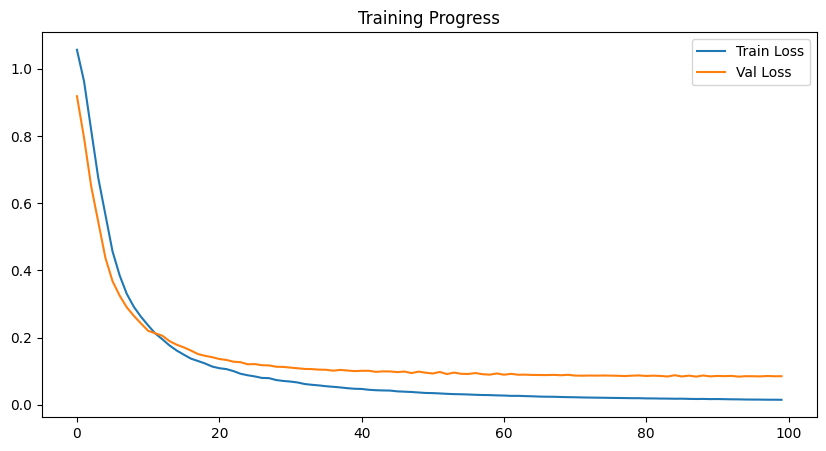

Ready for test plots and metrics.


In [495]:
# Build train/validation/test loaders, then train the LSTM.
train_loader, val_loader, test_loader, n_in, n_out, scaler, all_cols = prepare_session_split_data(
    CSV_FILE,
    INPUT_SENSORS,
    TARGET_SENSORS,
    window_size=WINDOW_SIZE,
    batch_size=BATCH_SIZE,
    train_session_ids=TRAIN_SESSION_IDS,
    test_session_ids=TEST_SESSION_IDS,
    validation_size=VALIDATION_SIZE,
    train_stride=TRAIN_STRIDE,
    val_stride=VAL_STRIDE,
    test_stride=TEST_STRIDE,
)

# Initialize model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Model channels: input={n_in}, output={n_out}")
model = GaitRNN(num_inputs=n_in, num_outputs=n_out, hidden_size=128)

# Train
train_losses, val_losses = train_engine(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    device=device,
    model_path=BEST_MODEL_PATH,
)

model_test_session_record = save_lstm_model_test_session_record(
    model_path=BEST_MODEL_PATH,
    subject=Subject,
    test_session_ids=getattr(test_loader.dataset, 'session_ids', TEST_SESSION_IDS),
)

# Plot loss curve
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training Progress')
plt.legend()
plt.show()

# Build denormalizer from the actual loader columns
in_cols = train_loader.dataset.input_names
tgt_cols = train_loader.dataset.target_names
all_process_cols = all_cols

denormalizer = Denormalizer(scaler, all_process_cols, tgt_cols, device=device)
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device)
model.eval()
print("Ready for test plots and metrics.")


In [496]:
# Optional quick checks.
# visualize_full_window(model, val_loader, denormalizer, device=device, idx=0, split_name='Validation')
# visualize_full_window(model, test_loader, denormalizer, device=device, idx=TEST_WINDOW_IDX, split_name='Test')


In [497]:
test_rmse, test_pcc, test_channel_metrics_dict = evaluate_metrics(
    model, test_loader, denormalizer, target_sensors=TARGET_SENSORS, device=device, split_name='Test'
)


========== Test 总体评估报告 ==========
总平均 PCC (波形相似度): 0.9776 (目标 > 0.9)
总平均 RMSE (物理量级数值): 0.3887

======== 单通道评估报告 ========
通道 [S1_acc_x_filtered] -> 平均 PCC: 0.9840 | 平均物理 RMSE: 0.9795
通道 [S1_acc_y_filtered] -> 平均 PCC: 0.9459 | 平均物理 RMSE: 0.5479
通道 [S1_acc_z_filtered] -> 平均 PCC: 0.9853 | 平均物理 RMSE: 0.6578
通道 [S1_gyro_x_filtered] -> 平均 PCC: 0.9425 | 平均物理 RMSE: 0.1295
通道 [S1_gyro_y_filtered] -> 平均 PCC: 0.9957 | 平均物理 RMSE: 0.2377
通道 [S1_gyro_z_filtered] -> 平均 PCC: 0.9655 | 平均物理 RMSE: 0.2395
通道 [S2_acc_x_filtered] -> 平均 PCC: 0.9882 | 平均物理 RMSE: 0.5263
通道 [S2_acc_y_filtered] -> 平均 PCC: 0.9846 | 平均物理 RMSE: 0.4491
通道 [S2_acc_z_filtered] -> 平均 PCC: 0.9833 | 平均物理 RMSE: 0.4314
通道 [S2_gyro_x_filtered] -> 平均 PCC: 0.9804 | 平均物理 RMSE: 0.1119
通道 [S2_gyro_y_filtered] -> 平均 PCC: 0.9949 | 平均物理 RMSE: 0.1463
通道 [S2_gyro_z_filtered] -> 平均 PCC: 0.9814 | 平均物理 RMSE: 0.2071


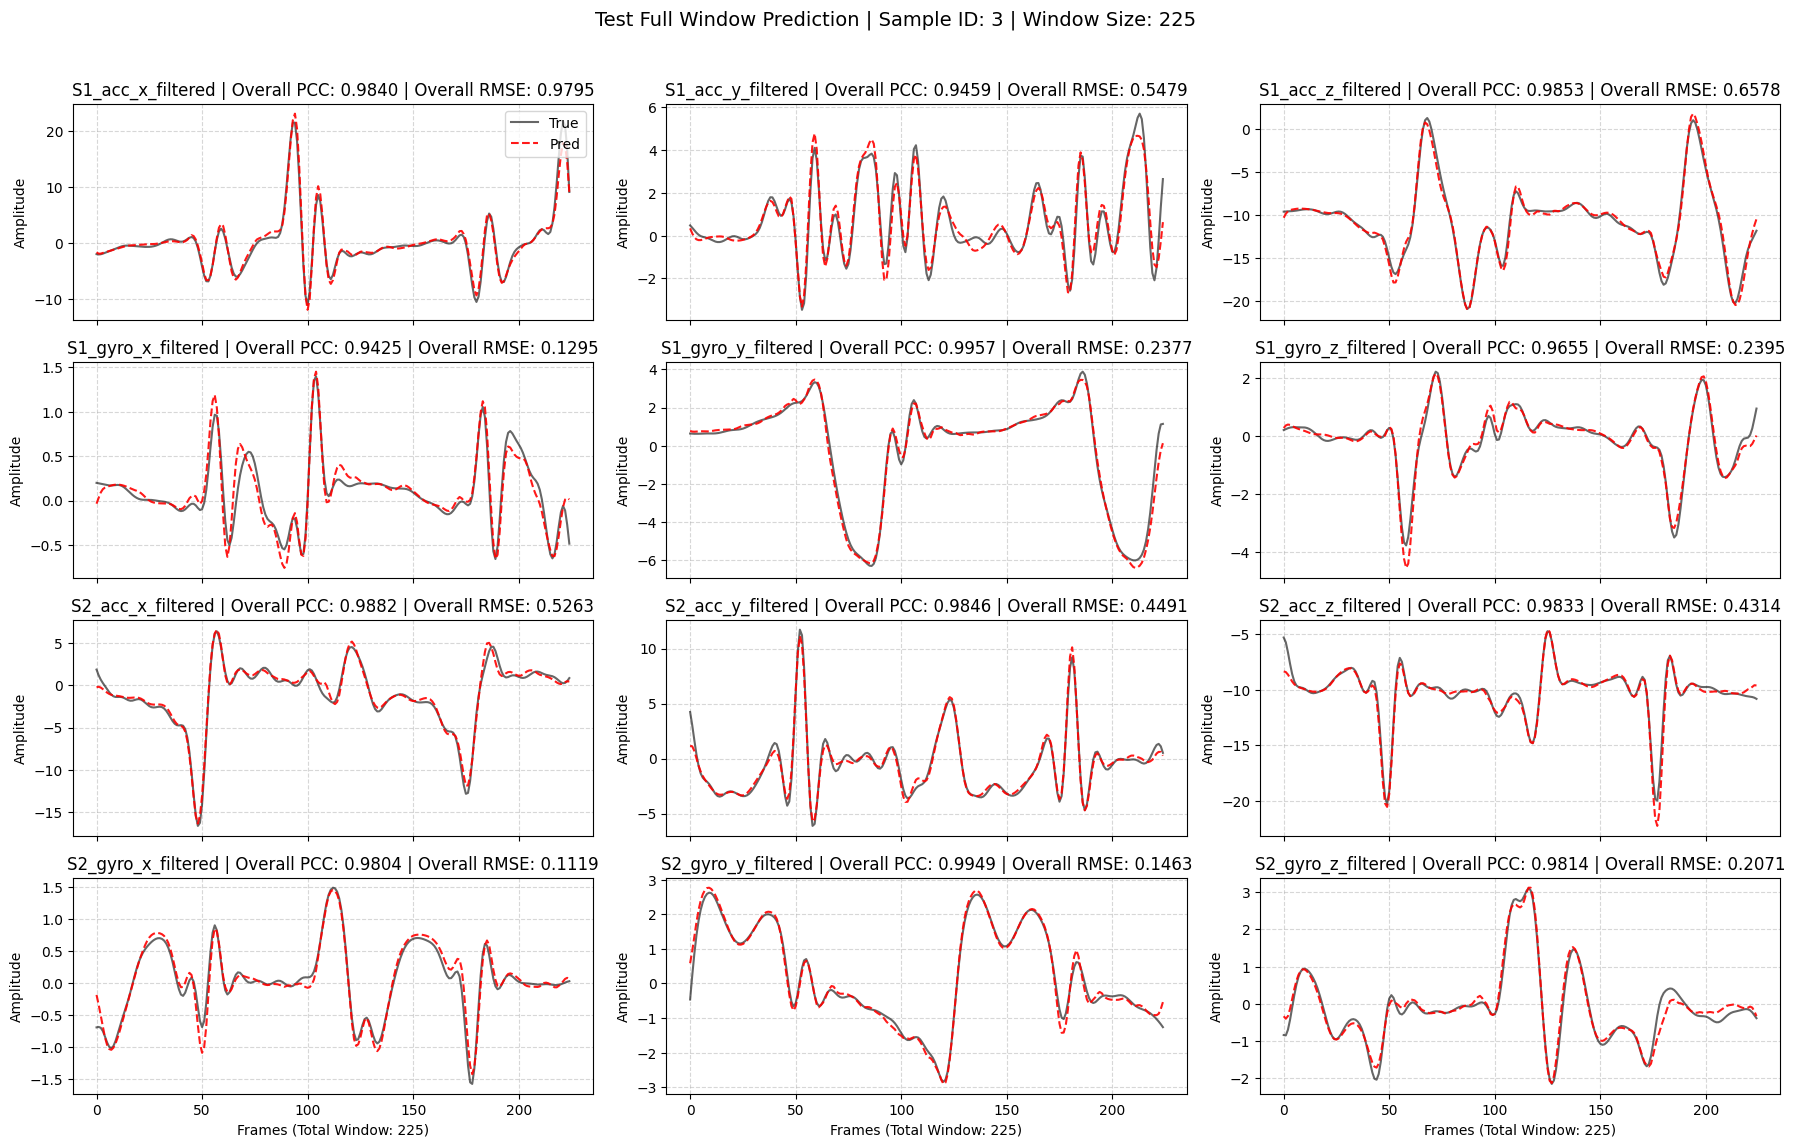

In [498]:
if not -len(test_loader.dataset) <= TEST_WINDOW_IDX < len(test_loader.dataset):
    raise ValueError(
        f"TEST_WINDOW_IDX={TEST_WINDOW_IDX} is outside the available range "
        f"[-{len(test_loader.dataset)}, {len(test_loader.dataset) - 1}]."
    )

visualize_full_window(
    model,
    test_loader,
    denormalizer,
    overall_metrics=test_channel_metrics_dict,
    device=device,
    idx=TEST_WINDOW_IDX,
    split_name='Test',
)


In [499]:
# Aggregate the existing per-axis xyz Test metrics into acc/gyro metrics for each target sensor.
from pathlib import Path

def _axis_metrics_for_group(channel_metrics, sensor, modality):
    prefix = f"{sensor}_{modality}_".lower()
    axis_order = {"x": 0, "y": 1, "z": 2}
    selected = []

    for channel_name, metrics in channel_metrics.items():
        channel_lower = channel_name.lower()
        if not channel_lower.startswith(prefix):
            continue

        parts = channel_lower.split("_")
        axis = parts[2] if len(parts) > 2 else ""
        axis_rank = axis_order.get(axis, 99)
        selected.append((axis_rank, axis, channel_name, metrics))

    selected.sort(key=lambda item: (item[0], item[2]))
    return {channel_name: metrics for _, _, channel_name, metrics in selected}


def _weighted_rmse(axis_metrics):
    weighted_mse_sum = 0.0
    weight_sum = 0

    for metrics in axis_metrics.values():
        axis_rmse = np.asarray(metrics.get("rmse", []), dtype=float)
        axis_rmse = axis_rmse[np.isfinite(axis_rmse)]
        if axis_rmse.size == 0:
            continue

        weighted_mse_sum += float(np.sum(axis_rmse ** 2))
        weight_sum += int(axis_rmse.size)

    if weight_sum == 0:
        return np.nan, 0
    return float(np.sqrt(weighted_mse_sum / weight_sum)), weight_sum


def _weighted_pcc(axis_metrics):
    weighted_pcc_sum = 0.0
    weight_sum = 0

    for metrics in axis_metrics.values():
        axis_pcc = np.asarray(metrics.get("pcc", []), dtype=float)
        axis_pcc = axis_pcc[np.isfinite(axis_pcc)]
        if axis_pcc.size == 0:
            continue

        weighted_pcc_sum += float(np.sum(axis_pcc))
        weight_sum += int(axis_pcc.size)

    if weight_sum == 0:
        return np.nan, 0
    return float(weighted_pcc_sum / weight_sum), weight_sum


def summarize_acc_gyro_weighted_metrics(channel_metrics, target_sensors):
    summary = {}
    detail_rows = []

    for sensor in target_sensors:
        for modality in ["acc", "gyro"]:
            axis_metrics = _axis_metrics_for_group(channel_metrics, sensor, modality)
            rmse, rmse_weight = _weighted_rmse(axis_metrics)
            pcc, pcc_weight = _weighted_pcc(axis_metrics)

            summary[f"{sensor}_{modality}_RMSE"] = rmse
            summary[f"{sensor}_{modality}_PCC"] = pcc
            detail_rows.append({
                "Subject": Subject,
                "TEST_SESSION_IDS": ",".join(map(str, TEST_SESSION_IDS)),
                "sensor": sensor,
                "modality": modality,
                "channels": ", ".join(axis_metrics.keys()),
                "RMSE_weight": rmse_weight,
                "PCC_weight": pcc_weight,
                "weighted_RMSE": rmse,
                "weighted_PCC": pcc,
            })

    requested_order = [
        "S1_acc_RMSE", "S1_gyro_RMSE", "S1_acc_PCC", "S1_gyro_PCC",
        "S2_acc_RMSE", "S2_gyro_RMSE", "S2_acc_PCC", "S2_gyro_PCC",
    ]
    fallback_order = [
        key
        for sensor in target_sensors
        for key in [
            f"{sensor}_acc_RMSE", f"{sensor}_gyro_RMSE",
            f"{sensor}_acc_PCC", f"{sensor}_gyro_PCC",
        ]
    ]
    ordered_columns = requested_order if all(key in summary for key in requested_order) else fallback_order

    summary_df = pd.DataFrame([{key: summary.get(key, np.nan) for key in ordered_columns}])
    detail_df = pd.DataFrame(detail_rows)
    return summary_df, detail_df


test_acc_gyro_metric_summary, test_acc_gyro_metric_details = summarize_acc_gyro_weighted_metrics(
    test_channel_metrics_dict,
    TARGET_SENSORS,
)

display(test_acc_gyro_metric_summary)
display(test_acc_gyro_metric_details)

metric_output_path = Path(f"{Subject}_test_acc_gyro_weighted_metrics.csv")
detail_output_path = Path(f"{Subject}_test_acc_gyro_weighted_metric_details.csv")
test_acc_gyro_metric_summary.to_csv(metric_output_path, index=False)
test_acc_gyro_metric_details.to_csv(detail_output_path, index=False)
print(f"Saved weighted Test acc/gyro metrics to: {metric_output_path}")
print(f"Saved metric grouping details to: {detail_output_path}")


,S1_acc_RMSE,S1_gyro_RMSE,S1_acc_PCC,S1_gyro_PCC,S2_acc_RMSE,S2_gyro_RMSE,S2_acc_PCC,S2_gyro_PCC
0,0.771827,0.210919,0.971743,0.967894,0.475392,0.164114,0.985376,0.98558


,Subject,TEST_SESSION_IDS,sensor,modality,channels,RMSE_weight,PCC_weight,weighted_RMSE,weighted_PCC
0,P8,10,S1,acc,"S1_acc_x_filtered, S1_acc_y_filtered, S1_acc_z...",27,27,0.771827,0.971743
1,P8,10,S1,gyro,"S1_gyro_x_filtered, S1_gyro_y_filtered, S1_gyr...",27,27,0.210919,0.967894
2,P8,10,S2,acc,"S2_acc_x_filtered, S2_acc_y_filtered, S2_acc_z...",27,27,0.475392,0.985376
3,P8,10,S2,gyro,"S2_gyro_x_filtered, S2_gyro_y_filtered, S2_gyr...",27,27,0.164114,0.985580


Saved weighted Test acc/gyro metrics to: P8_test_acc_gyro_weighted_metrics.csv
Saved metric grouping details to: P8_test_acc_gyro_weighted_metric_details.csv
